# *Laboratório II - Processamento Digital de Imagens -  Prof. Dr. Cassio Vinhal*
## Histogramas
Atividade desenvolvida para obtenção de nota parcial da disciplina de PDI - 2026.1.


## Parte I: Implementação do Histograma (Binning)
Nessa primeira parte, faremos a implementação do cálculo e a exibição de um histograma utilizando agrupamento (binning).


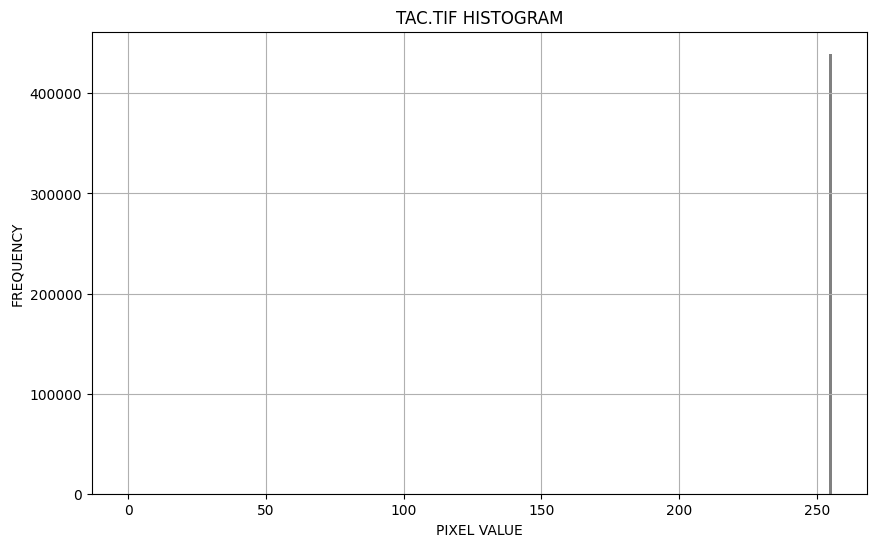

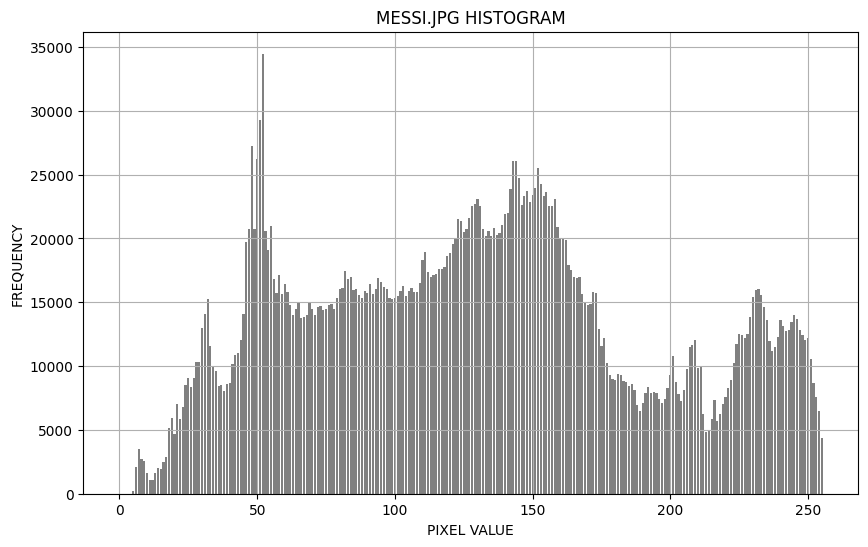

In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# abri a imagem e converte para escala de cinza
IMG = Image.open("tac.tif")
IMG = IMG.convert("L")

#obtém dados de altura e largura
WIDTH, HEIGHT = IMG.size

# transforma em matriz
IMAGE_MATRIX = []
for Y in range(HEIGHT):
    ROW = []
    for X in range(WIDTH):
        PIXEL = IMG.getpixel((X, Y))
        ROW.append(PIXEL)
    IMAGE_MATRIX.append(ROW)
    

def HISTOGRAM ( IMG_DATA , BINS =256) :
    HIST = np . zeros ( BINS , dtype = np . int64 )
    for PIXEL_VALUE in IMG_DATA . ravel () :
        HIST [ PIXEL_VALUE ] += 1
    return HIST



# para a função HISTOGRAM usa .ravel(), pois ela precisa de um array numpy
IMG_NUMPY_ARRAY = np.array(IMG)

# calcula o histograma 
HIST_DATA = HISTOGRAM(IMG_NUMPY_ARRAY)

# cria a figura e os eixos para o plot do histograma
plt.figure(figsize=(10, 6)) 
plt.bar(range(len(HIST_DATA)), HIST_DATA, color='gray')
plt.title("TAC.TIF HISTOGRAM") 
plt.xlabel("PIXEL VALUE")
plt.ylabel("FREQUENCY") 
plt.grid(True) 
plt.show() 

#outro exemplo, agora com imagem com maior variaçãos de tons de cinza
IMG2 = cv2.imread("messi.jpg") #já gera array em numpy
IMG2_GRAY= cv2.cvtColor(IMG2, cv2.COLOR_BGR2GRAY) #converte pra tons de cinza
HIST_DATA2 = HISTOGRAM(IMG2_GRAY)

plt.figure(figsize=(10, 6)) 
plt.bar(range(len(HIST_DATA2)), HIST_DATA2, color='gray')
plt.title("MESSI.JPG HISTOGRAM") 
plt.xlabel("PIXEL VALUE")
plt.ylabel("FREQUENCY") 
plt.grid(True) 
plt.show() 


Perguntas para reflexão  
*O que é o binning no contexto de histogramas? Como o número de bins influencia a visualização do histograma?*  
O binning é o agrupamento das intensidades dos pixels em faixas (bins) no histograma. A quantidade de bins define o detalhe do gráfico: menos bins deixam ele mais simples, mais bins deixam mais detalhado.

*Como a escolha de um número muito pequeno ou muito grande de bins pode afetar a interpretação dos dados?*  
Com poucos bins, perde-se detalhe e diferentes intensidades ficam muito misturadas. Com muitos bins, o histograma pode ficar fragmentado e destacar ruídos.

*Compare sua implementação Python com a implementação Java do Burger. Quais são as diferenças conceituais?*  
Na comparação, a implementação em Python é mais direta e didática, enquanto a do Burger em Java é mais estruturada e orientada a objetos. O conceito, porém, é o mesmo.

## Parte II: Histogramas Normalizado e Cumulativo

Nessa parte, implementaremos o histograma normalizado e cumulativo.

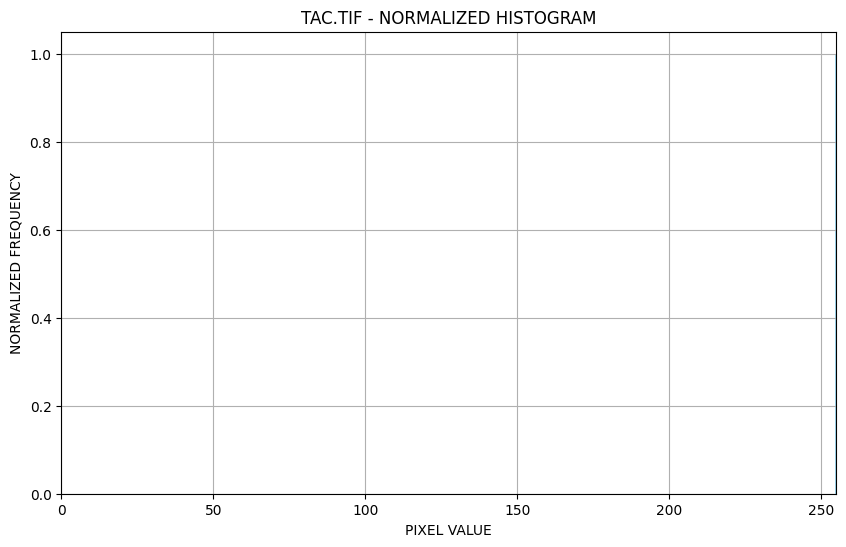

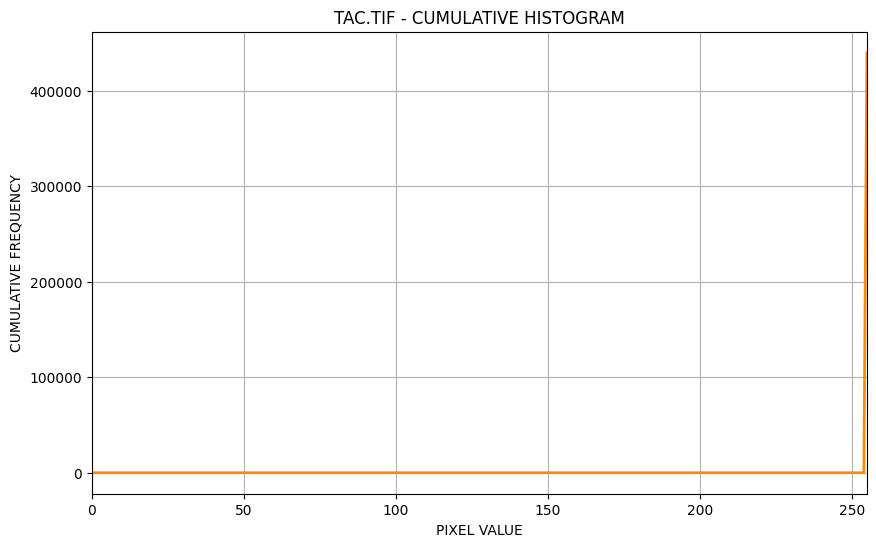

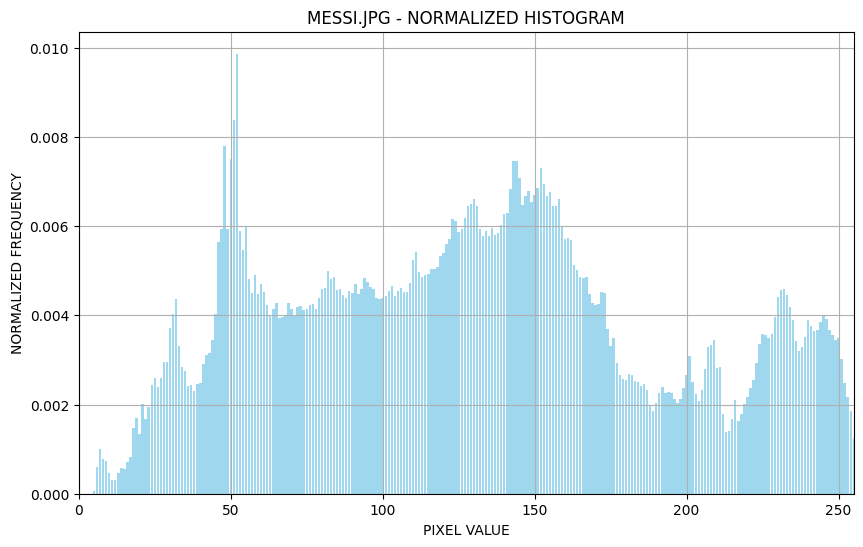

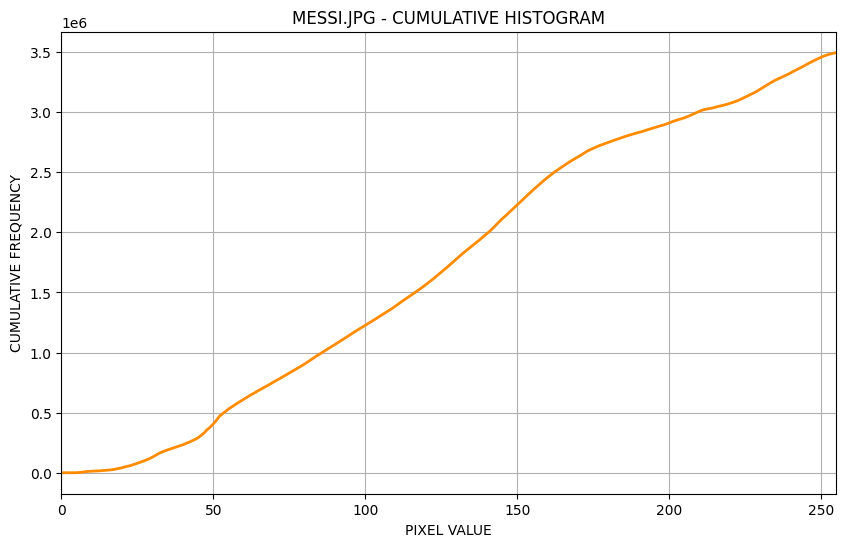

In [8]:

def CALCULATE_HISTOGRAMS(HIST_DATA):
    TOTAL_PIXELS = sum(HIST_DATA)

    # hist normalizado
    NORMALIZED_HIST = []
    for VALUE in HIST_DATA:
        NORMALIZED_HIST.append(VALUE / TOTAL_PIXELS)

    # hist cumulativo
    CUMULATIVE_HIST = []
    CUMULATIVE_SUM = 0

    for VALUE in HIST_DATA:
        CUMULATIVE_SUM += VALUE
        CUMULATIVE_HIST.append(CUMULATIVE_SUM)

    return NORMALIZED_HIST, CUMULATIVE_HIST



#invoca a função para a imagem em tons de cinza
NORMALIZED_HIST_1, CUMULATIVE_HIST_1 = CALCULATE_HISTOGRAMS(HIST_DATA)

plt.figure(figsize=(10, 6))
plt.bar(range(len(NORMALIZED_HIST_1)), NORMALIZED_HIST_1, color='skyblue', alpha=0.8)
plt.title("TAC.TIF - NORMALIZED HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("NORMALIZED FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(len(CUMULATIVE_HIST_1)), CUMULATIVE_HIST_1, color='darkorange', linewidth=2)
plt.title("TAC.TIF - CUMULATIVE HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("CUMULATIVE FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()


#invoca a função para imagem colorida (em tons de cinza)
NORMALIZED_HIST_2, CUMULATIVE_HIST_2 = CALCULATE_HISTOGRAMS(HIST_DATA2)

plt.figure(figsize=(10, 6))
plt.bar(range(len(NORMALIZED_HIST_2)), NORMALIZED_HIST_2, color='skyblue', alpha=0.8)
plt.title("MESSI.JPG - NORMALIZED HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("NORMALIZED FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(len(CUMULATIVE_HIST_2)), CUMULATIVE_HIST_2, color='darkorange', linewidth=2)
plt.title("MESSI.JPG - CUMULATIVE HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("CUMULATIVE FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()


Perguntas para Reflexão:  
*Qual a diferença entre o histograma absoluto, o normalizado e o cumulativo?*  
O histograma absoluto mostra a quantidade real de pixels em cada nível de intensidade. O histograma normalizado mostra a proporção ou probabilidade de cada intensidade, dividindo o número de pixels pelo total da imagem. Já o histograma cumulativo mostra a soma acumulada das frequências até cada nível de intensidade.

*Em quais situações o histograma cumulativo é mais útil para interpretar os dados da imagem?*  
O histograma cumulativo é mais útil quando se quer analisar a distribuição acumulada dos tons da imagem, especialmente em técnicas como equalização de histograma, ajuste de contraste e para ver rapidamente quantos pixels estão abaixo de certo nível de cinza.


*Como o histograma normalizado se relaciona com a função de distribuição de probabilidade da imagem?*  
O histograma normalizado se relaciona com a função de distribuição de probabilidade porque ele representa, para cada nível de intensidade, a probabilidade de um pixel da imagem ter aquele valor. Ou seja, ele pode ser visto como a PDF discreta da imagem.

## Parte III: Teste com Imagens em Tons de Cinza

Nessa parte, iremos aplicar o algoritmo em 3 imagens diferentes em tons de cinza com características distintas (clara, escura, alto contraste, baixo contraste).

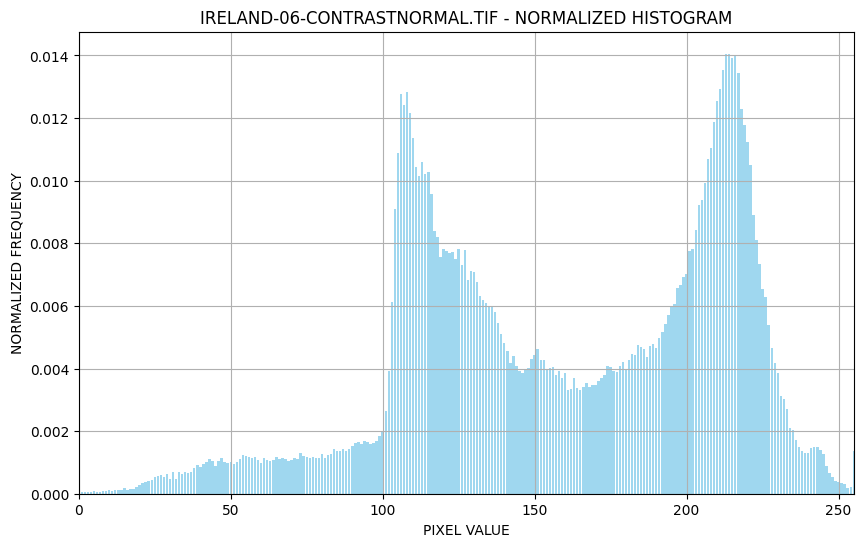

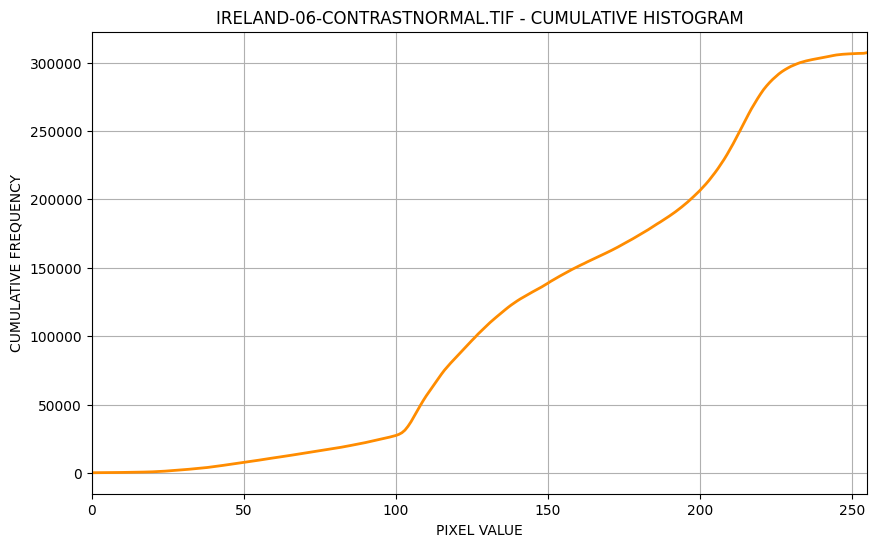

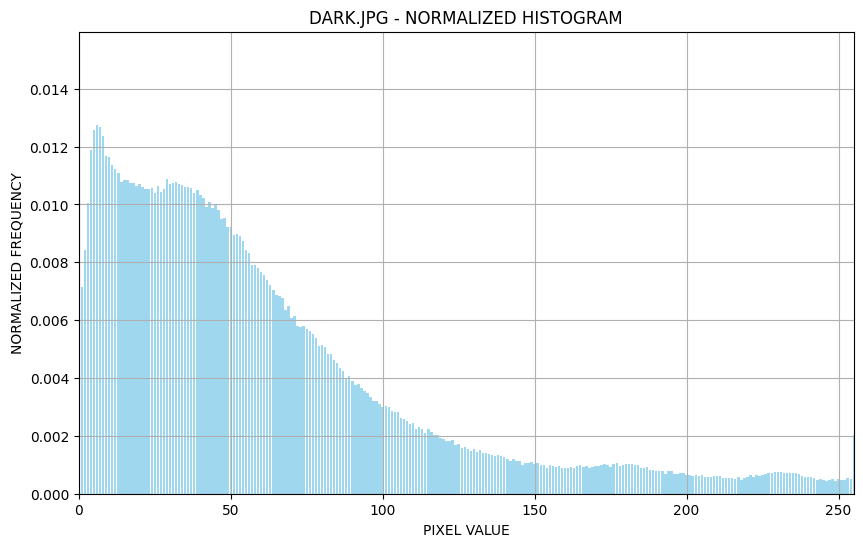

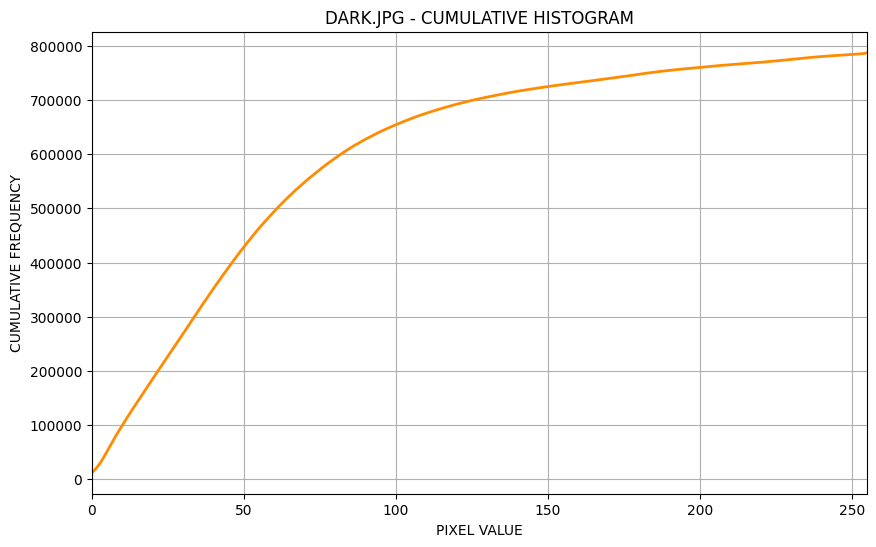

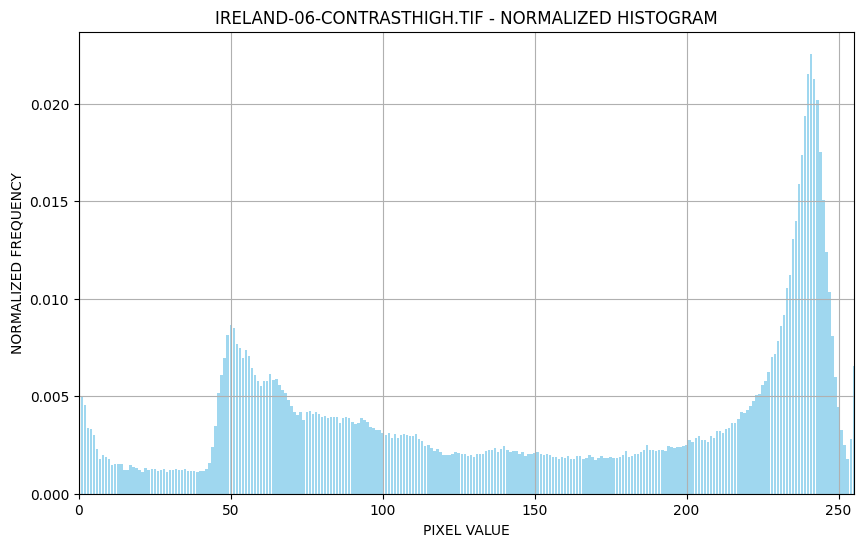

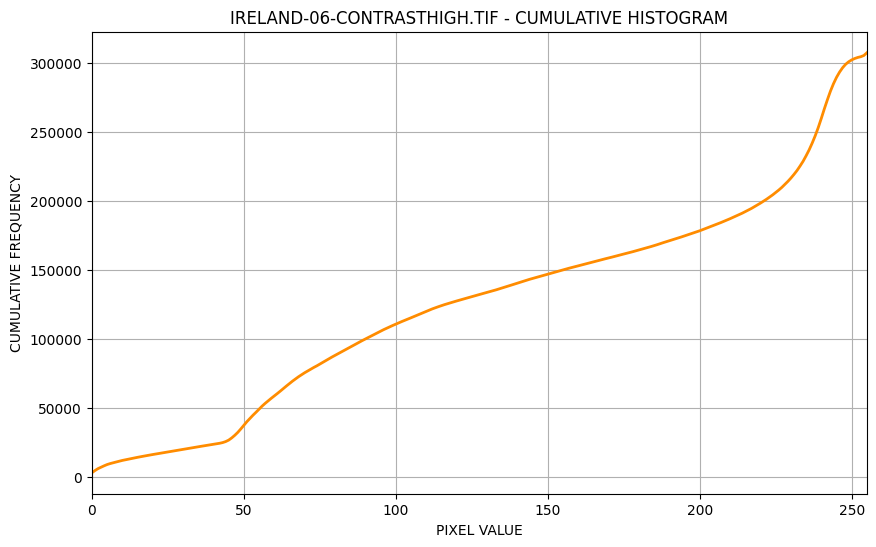

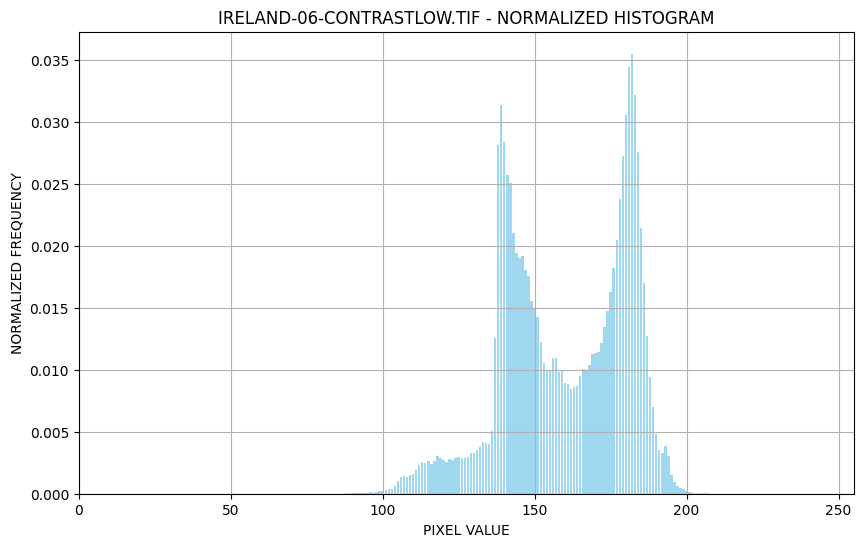

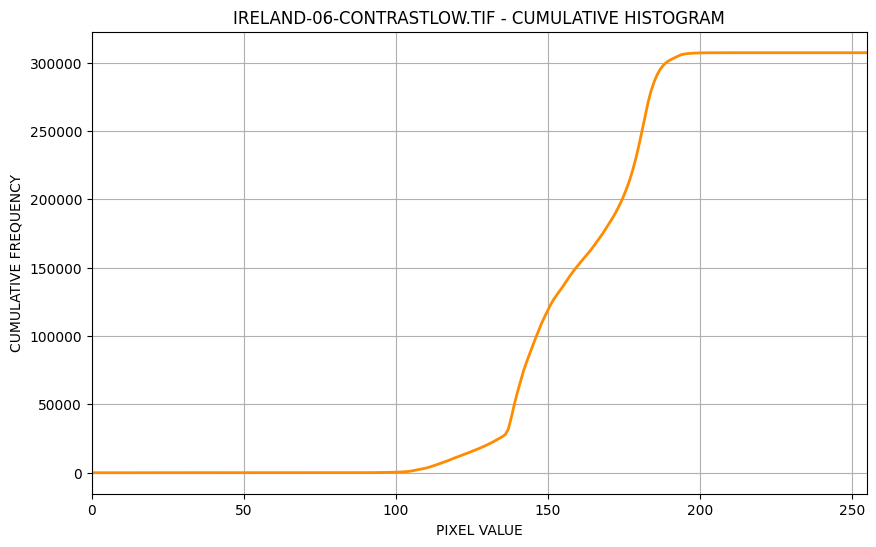

In [ ]:
#gerando os histogramas
LIGHT_IMAGE = cv2.imread("Archive/imagens/ireland-06-contrastnormal.tif", cv2.IMREAD_GRAYSCALE)
HIST_LIGHT = HISTOGRAM(LIGHT_IMAGE)
NORMALIZED_HIST_LIGHT, CUMULATIVE_HIST_LIGHT = CALCULATE_HISTOGRAMS(HIST_LIGHT)

#plotando os histogramas
plt.figure(figsize=(10, 6))
plt.bar(range(len(NORMALIZED_HIST_LIGHT)), NORMALIZED_HIST_LIGHT, color='skyblue', alpha=0.8)
plt.title("IRELAND-06-CONTRASTNORMAL.TIF - NORMALIZED HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("NORMALIZED FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(len(CUMULATIVE_HIST_LIGHT)), CUMULATIVE_HIST_LIGHT, color='darkorange', linewidth=2)
plt.title("IRELAND-06-CONTRASTNORMAL.TIF - CUMULATIVE HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("CUMULATIVE FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()

#gerando os histogramas
DARK_IMAGE = cv2.imread("dark.jpg", cv2.IMREAD_GRAYSCALE)
HIST_DARK = HISTOGRAM(DARK_IMAGE)
NORMALIZED_HIST_DARK, CUMULATIVE_HIST_DARK = CALCULATE_HISTOGRAMS(HIST_DARK)

#plotando os histogramas
plt.figure(figsize=(10, 6))
plt.bar(range(len(NORMALIZED_HIST_DARK)), NORMALIZED_HIST_DARK, color='skyblue', alpha=0.8)
plt.title("DARK.JPG - NORMALIZED HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("NORMALIZED FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(len(CUMULATIVE_HIST_DARK)), CUMULATIVE_HIST_DARK, color='darkorange', linewidth=2)
plt.title("DARK.JPG - CUMULATIVE HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("CUMULATIVE FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()

#gerando os histogramas
HIGH_CONTRAST_IMAGE = cv2.imread("Archive/imagens/ireland-06-contrasthigh.tif", cv2.IMREAD_GRAYSCALE)
HIST_HIGH_CONTRAST = HISTOGRAM(HIGH_CONTRAST_IMAGE)
NORMALIZED_HIST_HIGH_CONTRAST, CUMULATIVE_HIST_HIGH_CONTRAST = CALCULATE_HISTOGRAMS(HIST_HIGH_CONTRAST)

#plotando os histogramas
plt.figure(figsize=(10, 6))
plt.bar(range(len(NORMALIZED_HIST_HIGH_CONTRAST)), NORMALIZED_HIST_HIGH_CONTRAST, color='skyblue', alpha=0.8)
plt.title("IRELAND-06-CONTRASTHIGH.TIF - NORMALIZED HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("NORMALIZED FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(len(CUMULATIVE_HIST_HIGH_CONTRAST)), CUMULATIVE_HIST_HIGH_CONTRAST, color='darkorange', linewidth=2)
plt.title("IRELAND-06-CONTRASTHIGH.TIF - CUMULATIVE HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("CUMULATIVE FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()

#gerando os histogramas
LOW_CONTRAST_IMAGE = cv2.imread("Archive/imagens/ireland-06-contrastlow.tif", cv2.IMREAD_GRAYSCALE)
HIST_LOW_CONTRAST = HISTOGRAM(LOW_CONTRAST_IMAGE)
NORMALIZED_HIST_LOW_CONTRAST, CUMULATIVE_HIST_LOW_CONTRAST = CALCULATE_HISTOGRAMS(HIST_LOW_CONTRAST)

#plotando os histogramas
plt.figure(figsize=(10, 6))
plt.bar(range(len(NORMALIZED_HIST_LOW_CONTRAST)), NORMALIZED_HIST_LOW_CONTRAST, color='skyblue', alpha=0.8)
plt.title("IRELAND-06-CONTRASTLOW.TIF - NORMALIZED HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("NORMALIZED FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(len(CUMULATIVE_HIST_LOW_CONTRAST)), CUMULATIVE_HIST_LOW_CONTRAST, color='darkorange', linewidth=2)
plt.title("IRELAND-06-CONTRASTLOW.TIF - CUMULATIVE HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("CUMULATIVE FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()

Perguntas para reflexão  

*Como o histograma de uma imagem em tons de cinza reflete a distribuição de intensidades de luz?*  
O histograma de uma imagem em tons de cinza reflete a distribuição de intensidades de luz ao mostrar quantos pixels existem em cada nível de cinza, desde os tons escuros até os claros. Assim, ele indica se a imagem concentra mais pixels em regiões escuras, médias ou claras.  

*A partir do histograma de uma imagem, você consegue identificar possíveis manipulações na imagem? Justifique sua resposta.*  
Sim, em alguns casos é possível identificar possíveis manipulações pela forma do histograma, pois alterações como aumento de contraste, equalização, recortes de intensidade ou compressões podem gerar picos, lacunas ou distribuições incomuns. Porém, o histograma sozinho não prova a manipulação, apenas pode dar indícios.

*O que acontece no histograma quando a imagem possui pouca variação de intensidade (baixa variação de luz)?*  
Quando a imagem possui pouca variação de intensidade, o histograma tende a ficar concentrado em uma faixa estreita de valores, mostrando que poucos níveis de cinza estão sendo usados. Isso normalmente indica baixo contraste.

*Compare os histogramas de imagens claras vs escuras. O que você observa?*  
Em imagens claras, o histograma tende a se concentrar mais à direita, onde estão os tons mais altos. Em imagens escuras, ele tende a se concentrar mais à esquerda, onde estão os tons baixos. Isso mostra se predominam pixels claros ou escuros.



## Parte IV: Análise de Dynamic Range
Nessa parte, iremos analisar histogramas de imagens com diferentes dynamic ranges.


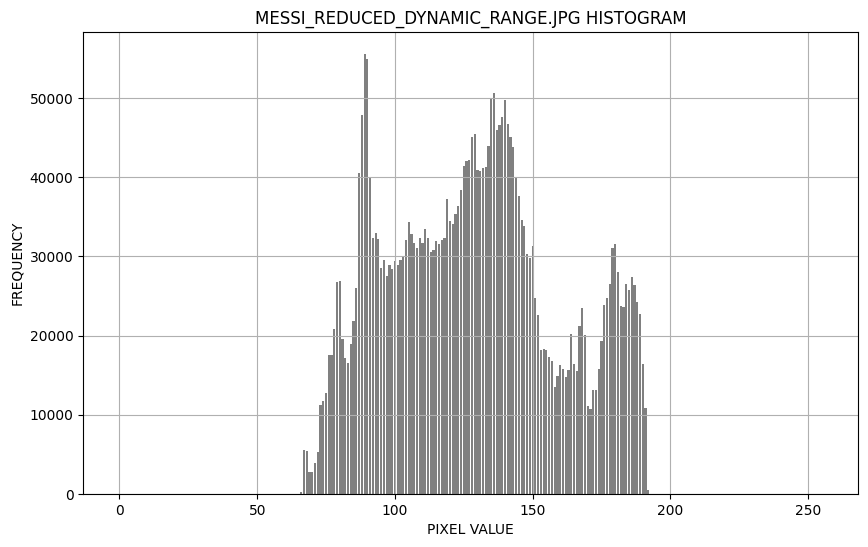

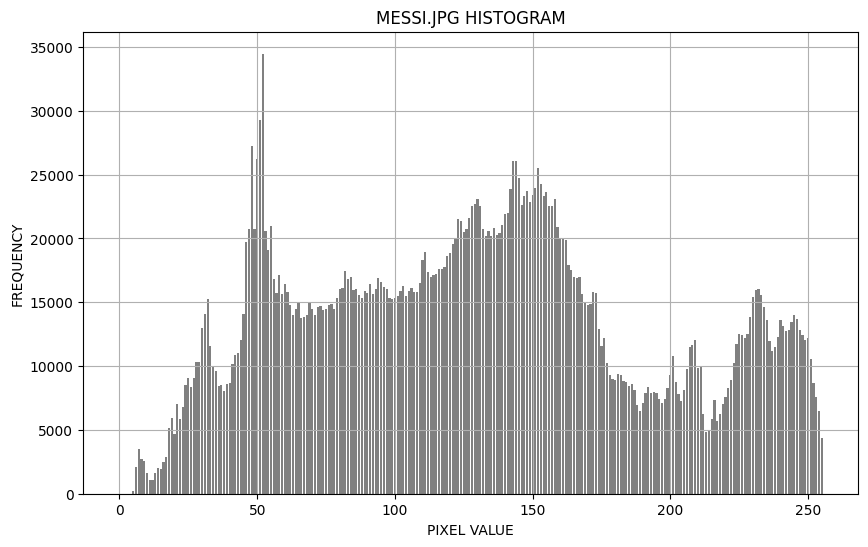

In [ ]:
# converte a imagem para float, centraliza os valores em 128 e comprime a distância até esse centro pela metade
REDUCED_RANGE_IMAGE = 128 + 0.5 * (IMG2_GRAY.astype(np.float32) - 128)

# garante que todos os valores fiquem entre 0 e 255 e converte de volta para uint8
REDUCED_RANGE_IMAGE = np.clip(REDUCED_RANGE_IMAGE, 0, 255).astype(np.uint8)

# salva a imagem
cv2.imwrite("messi_reduced_dynamic_range.jpg", REDUCED_RANGE_IMAGE)

#loada a imagem
IMAGE_REDUCED=cv2.imread("messi_reduced_dynamic_range.jpg",cv2.IMREAD_GRAYSCALE)

# gerando histograma da imagem reduzida
HIST_REDUCED = HISTOGRAM(IMAGE_REDUCED)

#plotando o histograma da imagem com menor escala que acabamos de gerar
plt.figure(figsize=(10, 6)) 
plt.bar(range(len(HIST_REDUCED)), HIST_REDUCED, color='gray')
plt.title("MESSI_REDUCED_DYNAMIC_RANGE.JPG HISTOGRAM") 
plt.xlabel("PIXEL VALUE")
plt.ylabel("FREQUENCY") 
plt.grid(True) 
plt.show() 

#plotando o histograma que fizemos anteriomente para essa imagem original
plt.figure(figsize=(10, 6)) 
plt.bar(range(len(HIST_DATA2)), HIST_DATA2, color='gray')
plt.title("MESSI.JPG HISTOGRAM") 
plt.xlabel("PIXEL VALUE")
plt.ylabel("FREQUENCY") 
plt.grid(True) 
plt.show() 

Perguntas para reflexão  
*O que é dynamic range e como ele se manifesta no histograma?*  
O dynamic range é a faixa de intensidades que a imagem utiliza, do tom mais escuro ao mais claro. No histograma, ele se manifesta pela largura da distribuição: quanto mais espalhado o histograma, maior o alcance de tons usados.  

*Como uma imagem com baixo dynamic range difere de uma com alto dynamic range em termos de histograma?*  
Uma imagem com baixo dynamic range tem histograma mais concentrado em uma faixa pequena de intensidades, enquanto uma com alto dynamic range tem histograma mais espalhado, ocupando uma faixa maior de níveis de cinza.  

*Qual a relação entre dynamic range e contraste da imagem?*  
A relação com o contraste é direta: quanto maior o dynamic range, maior tende a ser o contraste, pois a imagem usa melhor a diferença entre tons escuros e claros. Já um baixo dynamic range geralmente indica baixo contraste.  


## Parte V: Histogramas de Imagens Coloridas
Nessa parte, iremos implementar o cálculo de histogramas separados para cada canal de cor (R, G, B).


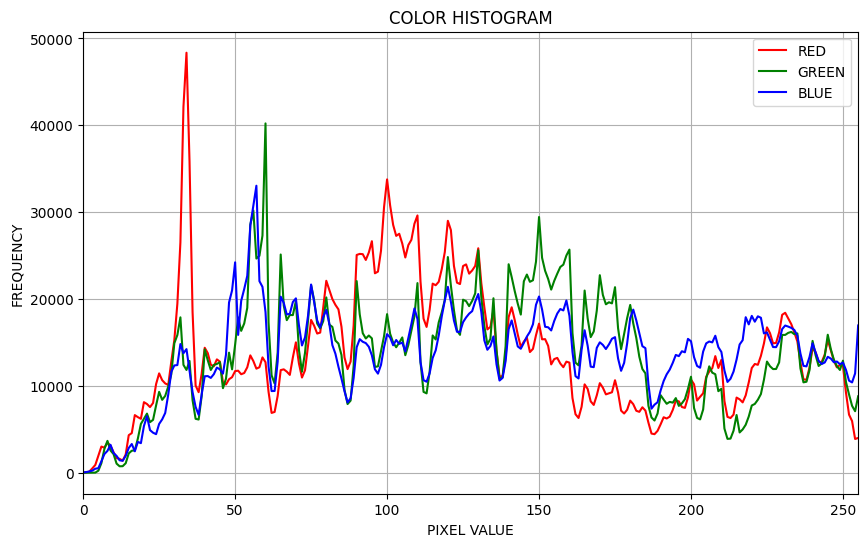

In [11]:
def HISTOGRAM_COLOR(IMG_DATA, BINS=256):
    # cria um vetor de zeros para armazenar as contagens do histograma do canal azul, verbe e vermelho
    HIST_B = np.zeros(BINS, dtype=np.int64)
    HIST_G = np.zeros(BINS, dtype=np.int64)
    HIST_R = np.zeros(BINS, dtype=np.int64)

    # percorre todos os valores de intensidade do canal azul, verde e vermelho, e depois incrementa a posição correspondente ao valor do pixel no respectivo histograma 
    for PIXEL_VALUE in IMG_DATA[:, :, 0].ravel():
        HIST_B[PIXEL_VALUE] += 1
    for PIXEL_VALUE in IMG_DATA[:, :, 1].ravel():
        HIST_G[PIXEL_VALUE] += 1
    for PIXEL_VALUE in IMG_DATA[:, :, 2].ravel():
        HIST_R[PIXEL_VALUE] += 1

    return HIST_R, HIST_G, HIST_B

# loada nossa imagem colorida
IMG_COLOR = cv2.imread("messi.jpg")

#invoca o histograma para RGB
HIST_R, HIST_G, HIST_B = HISTOGRAM_COLOR(IMG_COLOR)

# plota o histograma
plt.figure(figsize=(10, 6))
plt.plot(HIST_R, color='red', label='RED')
plt.plot(HIST_G, color='green', label='GREEN')
plt.plot(HIST_B, color='blue', label='BLUE')
plt.title("COLOR HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("FREQUENCY")
plt.xlim(0, 255)
plt.grid(True)
plt.legend()
plt.show()


## Parte VI: Comparação com implementações prontas
Nessa parte, iremos comparar os resultados da nossa implementação manual com cv2.calcHist() e plt.hist().


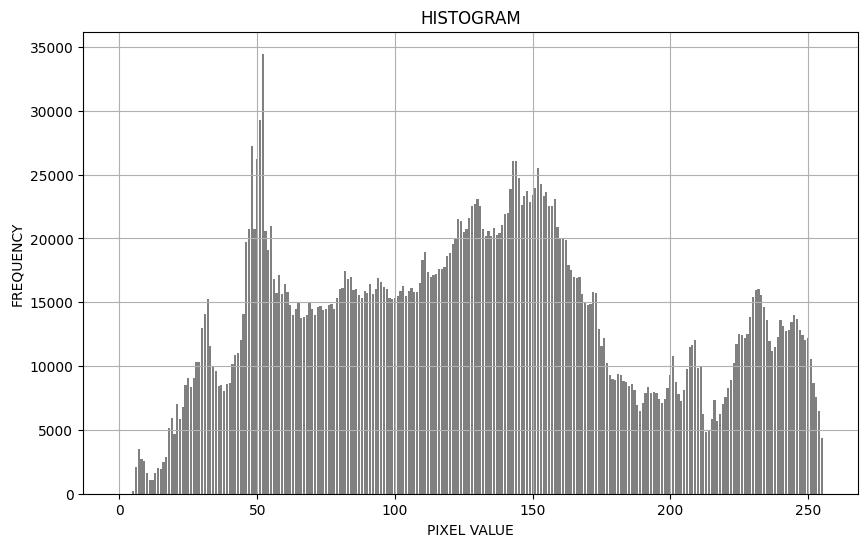

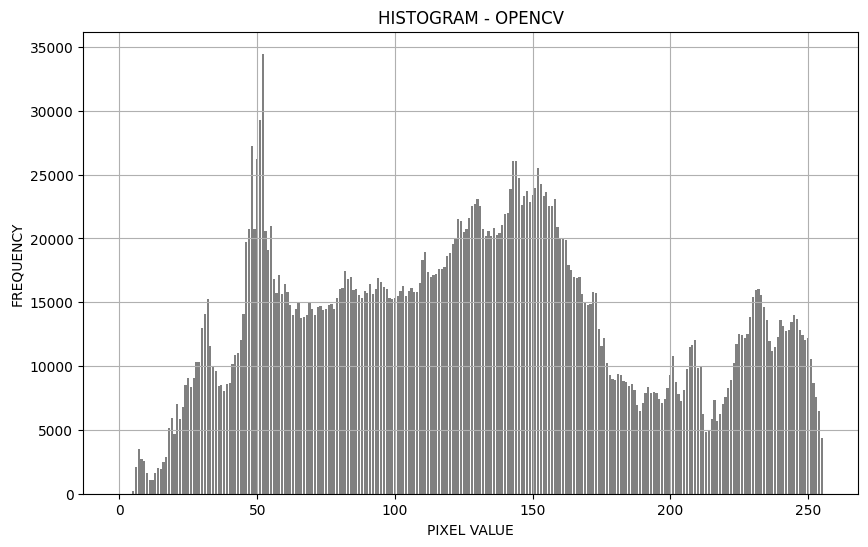

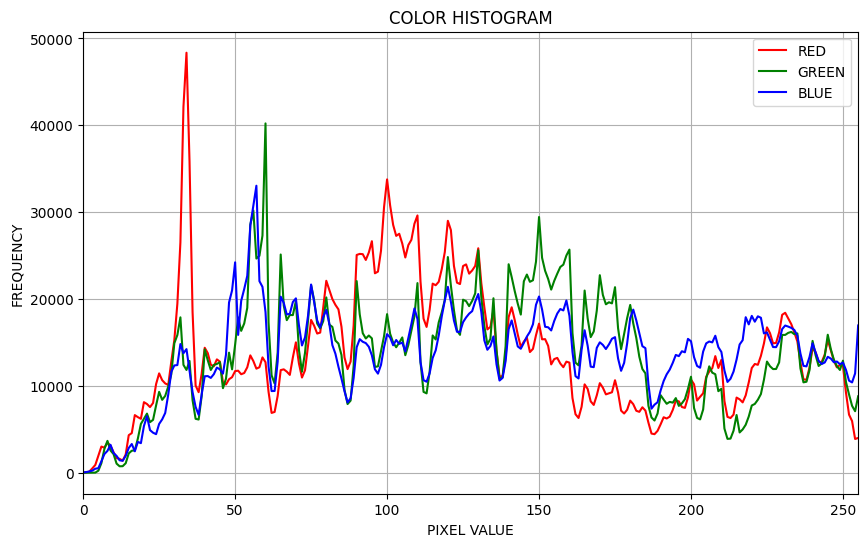

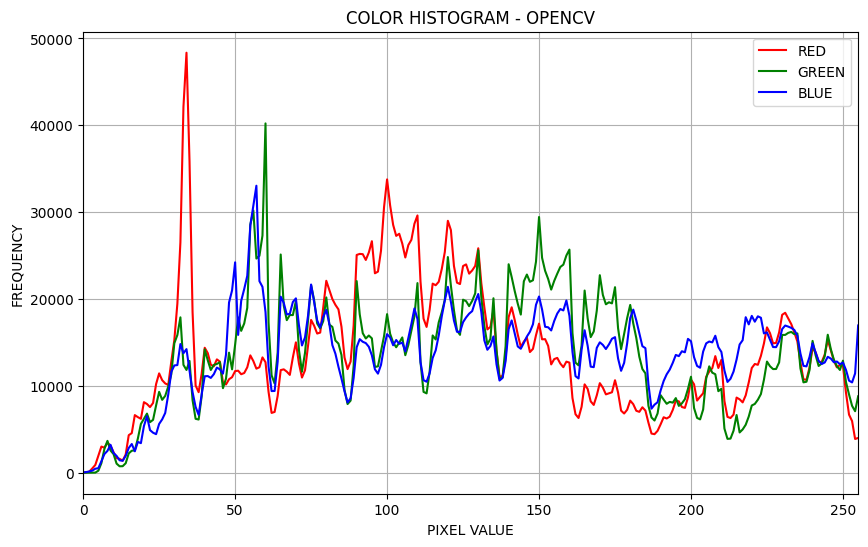

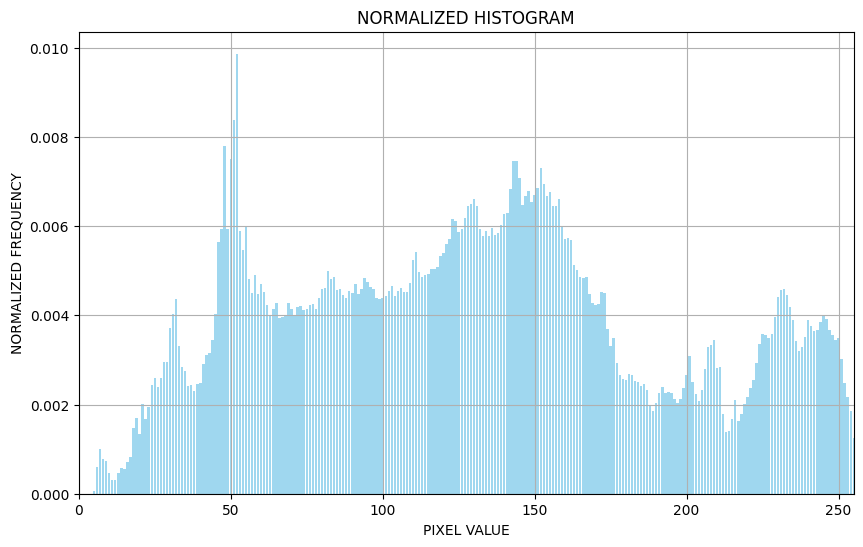

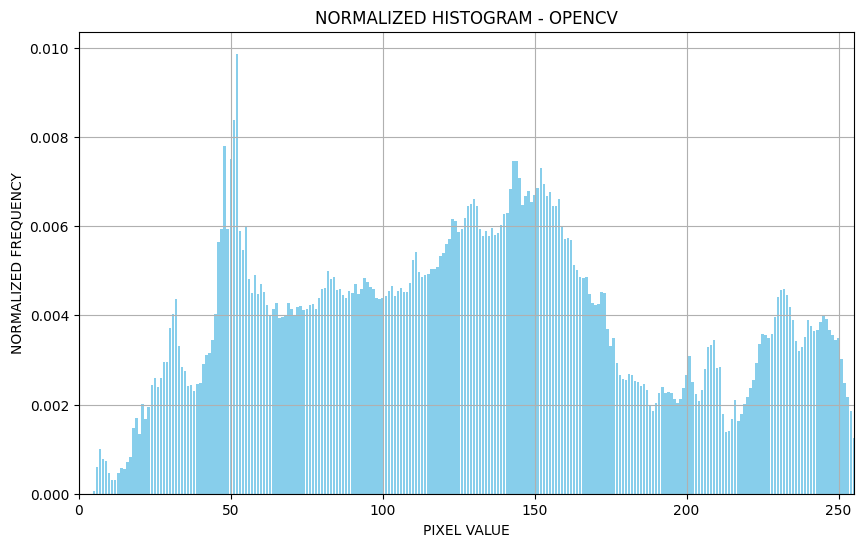

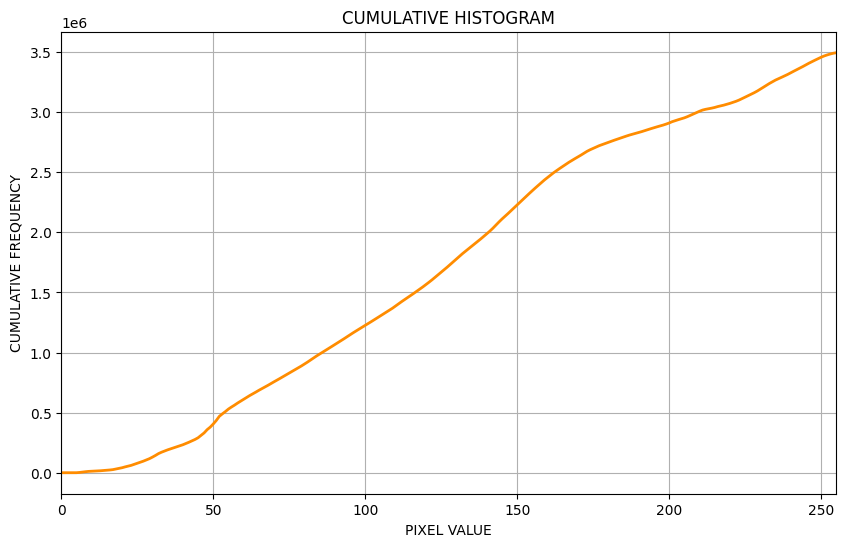

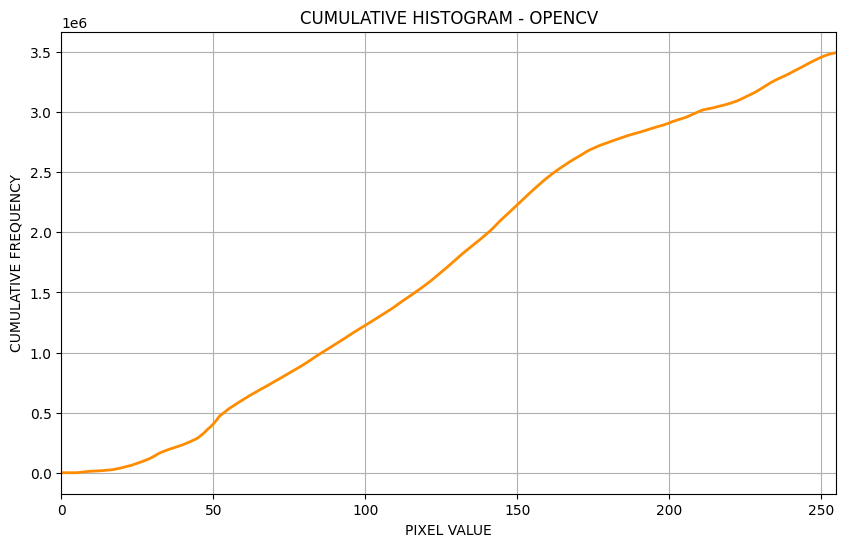

In [12]:
#plotando o histograma padrão que obtivemos na parte I
plt.figure(figsize=(10, 6)) 
plt.bar(range(len(HIST_DATA2)), HIST_DATA2, color='gray')
plt.title("HISTOGRAM") 
plt.xlabel("PIXEL VALUE")
plt.ylabel("FREQUENCY") 
plt.grid(True) 
plt.show() 


HIST_DATA3 = cv2.calcHist([IMG2_GRAY], [0], None, [256], [0, 256]).flatten()
#plotando o histograma do cv2
plt.figure(figsize=(10, 6)) 
plt.bar(range(len(HIST_DATA3)), HIST_DATA3, color='gray')
plt.title("HISTOGRAM - OPENCV") 
plt.xlabel("PIXEL VALUE")
plt.ylabel("FREQUENCY") 
plt.grid(True) 
plt.show() 

#plotando o histograma colorido que obtivemos na parte V
plt.figure(figsize=(10, 6))
plt.plot(HIST_R, color='red', label='RED')
plt.plot(HIST_G, color='green', label='GREEN')
plt.plot(HIST_B, color='blue', label='BLUE')
plt.title("COLOR HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("FREQUENCY")
plt.xlim(0, 255)
plt.grid(True)
plt.legend()
plt.show()

HIST_B = cv2.calcHist([IMG2], [0], None, [256], [0, 256]).flatten()
HIST_G = cv2.calcHist([IMG2], [1], None, [256], [0, 256]).flatten()
HIST_R = cv2.calcHist([IMG2], [2], None, [256], [0, 256]).flatten()
#plotando o histograma colorido do cv2
plt.figure(figsize=(10, 6))
plt.plot(HIST_R, color='red', label='RED')
plt.plot(HIST_G, color='green', label='GREEN')
plt.plot(HIST_B, color='blue', label='BLUE')
plt.title("COLOR HISTOGRAM - OPENCV")
plt.xlabel("PIXEL VALUE")
plt.ylabel("FREQUENCY")
plt.xlim(0, 255)
plt.grid(True)
plt.legend()
plt.show()

#plotando o histograma normalizado que obtivemos na parte II
plt.figure(figsize=(10, 6))
plt.bar(range(len(NORMALIZED_HIST_2)), NORMALIZED_HIST_2, color='skyblue', alpha=0.8)
plt.title("NORMALIZED HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("NORMALIZED FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()

TOTAL_PIXELS = IMG2_GRAY.shape[0] * IMG2_GRAY.shape[1]
NORMALIZED_HIST = HIST_DATA3 / TOTAL_PIXELS
#plotando o histograma normalizado do cv2
plt.figure(figsize=(10, 6))
plt.bar(range(len(NORMALIZED_HIST)), NORMALIZED_HIST, color='skyblue')
plt.title("NORMALIZED HISTOGRAM - OPENCV")
plt.xlabel("PIXEL VALUE")
plt.ylabel("NORMALIZED FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()


#plotando o histograma cumulativo que obtivemos na parte II
plt.figure(figsize=(10, 6))
plt.plot(range(len(CUMULATIVE_HIST_2)), CUMULATIVE_HIST_2, color='darkorange', linewidth=2)
plt.title("CUMULATIVE HISTOGRAM")
plt.xlabel("PIXEL VALUE")
plt.ylabel("CUMULATIVE FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()

CUMULATIVE_HIST = np.cumsum(HIST_DATA3)
#plotando o histograma cumulativo do opencv
plt.figure(figsize=(10, 6))
plt.plot(range(len(CUMULATIVE_HIST)), CUMULATIVE_HIST, color='darkorange', linewidth=2)
plt.title("CUMULATIVE HISTOGRAM - OPENCV")
plt.xlabel("PIXEL VALUE")
plt.ylabel("CUMULATIVE FREQUENCY")
plt.grid(True)
plt.xlim(0, 255)
plt.show()


Perguntas para reflexão  
*Sua implementação manual produziu os mesmos resultados das funções prontas?*  
Sim, em geral a implementação manual deve produzir os mesmos resultados das funções prontas, desde que o cálculo do histograma seja feito corretamente. Diferenças pequenas podem aparecer por detalhes de normalização, número de bins ou tratamento dos dados.

*Quais as vantagens e desvantagens de implementar manualmente vs usar funções prontas?*  
Implementar manualmente tem a vantagem de facilitar o entendimento do algoritmo e dar mais controle sobre cada etapa, mas é mais trabalhoso e sujeito a erros. Já as funções prontas são mais rápidas, confiáveis e práticas, porém escondem parte da lógica interna.

*Em termos de performance, qual abordagem seria mais eficiente para imagens grandes?*   
Em imagens grandes, as funções prontas costumam ser mais eficientes, pois geralmente são otimizadas e usam implementações internas mais rápidas do que um código manual simples.